# 01 — Data Cleaning & Preparation

**Owner:** Person A
**Dataset:** [UCI Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) (red and white Vinho Verde wines)
**Goal of the project:** classify wines as **good** (quality ≥ 7) or **not good** (quality < 7).

This notebook:
1. Loads the red and white wine files
2. Combines them into one table with a `type` column
3. Checks data types, missing values, duplicates, and outliers
4. Creates the target label `is_good`
5. Splits the data into train and test sets
6. Saves the cleaned files for EDA (Person B) and modeling (Person C)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Settings used throughout the notebook
DATA_DIR = "../data"
GOOD_THRESHOLD = 7      # a wine is "good" if quality >= 7
TEST_SIZE = 0.2         # 80% train / 20% test
RANDOM_STATE = 42       # makes the split reproducible

## 1. Load the data

The UCI files use a semicolon (`;`) as the separator, not a comma.

In [2]:
red = pd.read_csv(f"{DATA_DIR}/winequality-red.csv", sep=";")
white = pd.read_csv(f"{DATA_DIR}/winequality-white.csv", sep=";")

print("Red wines:  ", red.shape)
print("White wines:", white.shape)
red.head()

Red wines:   (1599, 12)
White wines: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Combine red and white

We stack both files into one table and add a `type` column so we still know which
wine is which. Combining gives us more data to learn from, and the `type` column
lets the model (and EDA) take wine color into account.

We also rename the columns to `snake_case` (e.g. `fixed acidity` → `fixed_acidity`)
so they are easier to use in code.

In [3]:
red["type"] = "red"
white["type"] = "white"

wine = pd.concat([red, white], ignore_index=True)
wine.columns = wine.columns.str.strip().str.replace(" ", "_")

print("Combined shape:", wine.shape)
wine["type"].value_counts()

Combined shape: (6497, 13)


type
white    4898
red      1599
Name: count, dtype: int64

## 3. Check data types

All 11 chemical measurements should be numeric, `quality` should be an integer,
and `type` should be text.

In [4]:
wine.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                        str
dtype: object

## 4. Check for missing values

In [5]:
missing = wine.isna().sum()
print("Total missing values:", missing.sum())
missing

Total missing values: 0


fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

**Result:** there are no missing values, so no imputation is needed.

## 5. Check for duplicates

A duplicate is a row where **every** column (including `type` and `quality`) is identical
to another row.

In [6]:
dup_mask = wine.duplicated()
print("Duplicate rows:", dup_mask.sum())
print("Share of data: ", round(dup_mask.mean() * 100, 1), "%")
wine[dup_mask]["type"].value_counts()

Duplicate rows: 1177
Share of data:  18.1 %


type
white    937
red      240
Name: count, dtype: int64

**Decision: drop exact duplicates (keep the first copy).**

About 18% of rows are exact copies. Some might be different wines that happened to
measure the same, but with 11 measurements recorded to several decimal places that is
unlikely for this many rows. Keeping them would also be risky for modeling: the same row
could end up in both the train and test set, which makes the model look better than it
really is (data leakage).

In [7]:
rows_before = len(wine)
wine = wine.drop_duplicates().reset_index(drop=True)

print("Rows before:", rows_before)
print("Rows after: ", len(wine))
print("Removed:    ", rows_before - len(wine))

Rows before: 6497
Rows after:  5320
Removed:     1177


## 6. Check for outliers

We use the **IQR rule**: a value is an outlier if it is more than 1.5 × IQR below
the 25th percentile or above the 75th percentile.

In [8]:
features = wine.columns.drop(["quality", "type"])

q1 = wine[features].quantile(0.25)
q3 = wine[features].quantile(0.75)
iqr = q3 - q1
is_outlier = (wine[features] < q1 - 1.5 * iqr) | (wine[features] > q3 + 1.5 * iqr)

outlier_summary = pd.DataFrame({
    "outliers": is_outlier.sum(),
    "percent": (is_outlier.mean() * 100).round(1),
    "min": wine[features].min(),
    "max": wine[features].max(),
}).sort_values("outliers", ascending=False)
outlier_summary

,outliers,percent,min,max
fixed_acidity,304,5.7,3.80000,15.90000
volatile_acidity,279,5.2,0.08000,1.58000
chlorides,237,4.5,0.00900,0.61100
sulphates,163,3.1,0.22000,2.00000
citric_acid,143,2.7,0.00000,1.66000
residual_sugar,141,2.7,0.60000,65.80000
pH,49,0.9,2.72000,4.01000
free_sulfur_dioxide,44,0.8,1.00000,289.00000
total_sulfur_dioxide,10,0.2,6.00000,440.00000
density,3,0.1,0.98711,1.03898


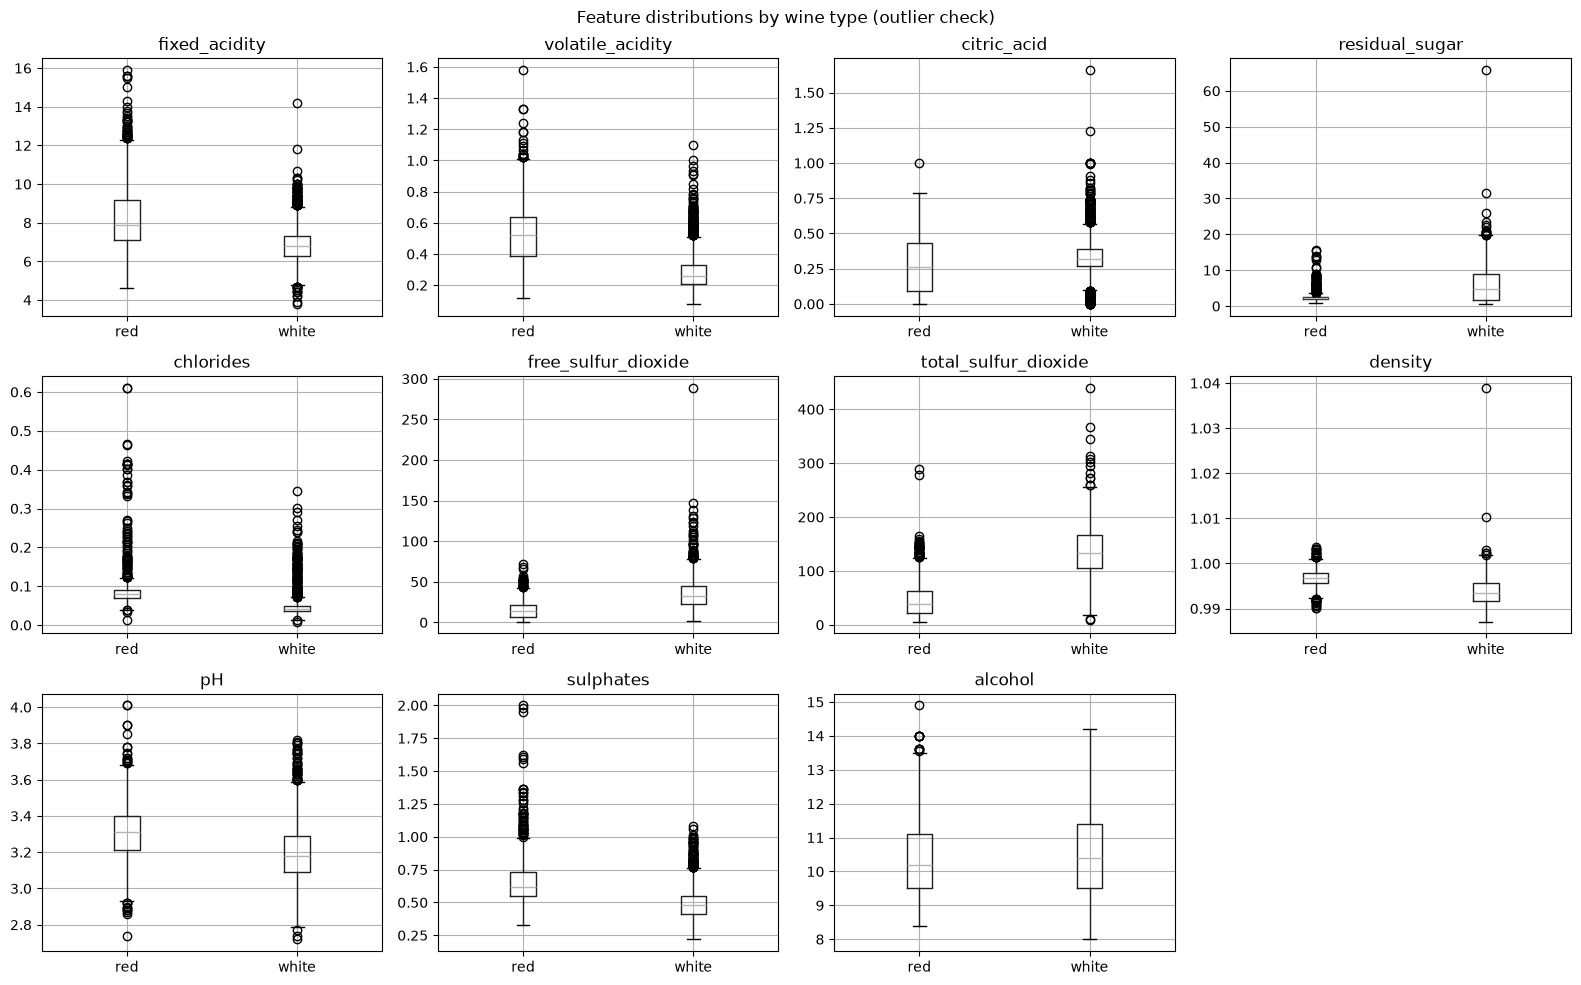

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, features):
    wine.boxplot(column=col, by="type", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Feature distributions by wine type (outlier check)")
plt.tight_layout()
plt.show()

**Decision: keep the outliers.**

- Many "outliers" come from mixing red and white wines, which naturally have different
  chemistry (e.g. white wines have much more sulfur dioxide, red wines more volatile acidity).
- The extreme values (like very high residual sugar in sweet wines) are chemically
  plausible, so they are most likely real wines, not data-entry errors.
- Removing them would throw away real information. If Person C finds that outliers hurt a
  specific model, scaling or tree-based models can handle them.

## 7. Create the target label

We turn `quality` (a score from 3 to 9) into a yes/no label:

- `is_good = 1` if quality ≥ 7
- `is_good = 0` otherwise

We also add `is_red` (1 = red, 0 = white) so models can use wine color as a number.

In [10]:
wine["is_good"] = (wine["quality"] >= GOOD_THRESHOLD).astype(int)
wine["is_red"] = (wine["type"] == "red").astype(int)

print("Quality score counts:")
print(wine["quality"].value_counts().sort_index())
print()
print("Target balance:")
print(wine["is_good"].value_counts())
print("Share of good wines:", round(wine["is_good"].mean() * 100, 1), "%")

Quality score counts:
quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

Target balance:
is_good
0    4311
1    1009
Name: count, dtype: int64
Share of good wines: 19.0 %


**Note for modeling:** only about 1 in 5 wines is "good", so the classes are imbalanced.
Accuracy alone will be misleading (a model that always says "not good" would be ~80%
accurate). Person C should look at precision, recall, F1, and ROC-AUC, and may want
to use `class_weight="balanced"`.

## 8. Train/test split

- **80% train / 20% test**
- **Stratified** on `is_good`, so both sets keep the same share of good wines
- `random_state=42` so everyone gets the exact same split

Scaling is **not** done here on purpose. Scalers must be fit on the training data only,
so that step belongs in the modeling notebook.

In [11]:
train, test = train_test_split(
    wine,
    test_size=TEST_SIZE,
    stratify=wine["is_good"],
    random_state=RANDOM_STATE,
)

print("Train:", train.shape, "- good share:", round(train["is_good"].mean() * 100, 1), "%")
print("Test: ", test.shape, "- good share:", round(test["is_good"].mean() * 100, 1), "%")

Train: (4256, 15) - good share: 19.0 %
Test:  (1064, 15) - good share: 19.0 %


## 9. Save the cleaned data

In [12]:
wine.to_csv(f"{DATA_DIR}/wine_clean.csv", index=False)
train.to_csv(f"{DATA_DIR}/train.csv", index=False)
test.to_csv(f"{DATA_DIR}/test.csv", index=False)

print("Saved wine_clean.csv, train.csv, test.csv to", DATA_DIR)

Saved wine_clean.csv, train.csv, test.csv to ../data


## Summary / handoff to Person B and Person C

| Step | What we did |
|---|---|
| Load | Read red (1,599) and white (4,898) wine files |
| Combine | Stacked into one table with a `type` column; renamed columns to snake_case |
| Data types | All features numeric, `quality` integer, `type` text; no changes needed |
| Missing values | None found |
| Duplicates | Dropped 1,177 exact duplicate rows → 5,320 rows remain |
| Outliers | Checked with the IQR rule; **kept** because they look like real wines |
| Target | `is_good` = 1 if quality ≥ 7 (about 19% of wines) |
| Extra column | `is_red` = 1 for red, 0 for white |
| Split | 80/20 stratified train/test split, `random_state=42` |

**Files:**
- `data/wine_clean.csv` — full cleaned dataset (use this for **EDA**)
- `data/train.csv`, `data/test.csv` — use these for **modeling**

**Heads-up for modeling:** drop `quality` and `type` from the model inputs.
`quality` is the answer that `is_good` comes from (using it would be cheating), and
`type` is already covered by `is_red`.